# 01 · Exploración, particiones y fugas

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


## Inspeccionar antes de entrenar
Comparar tamaños y prevalencias. No inventar fechas completas a partir del orden.

In [2]:
summary=pd.DataFrame([{"particion":n,"n":len(f),"prevalencia":(f.y=="yes").mean(),"inicio":f.row_id.min(),"fin":f.row_id.max()} for n,f in [("train",train),("validation",validation),("test",test)]])
display(summary);display(data.head())

,particion,n,prevalencia,inicio,fin
0,train,27126,0.050394,0,27125
1,validation,9042,0.117894,27126,36167
2,test,9043,0.315824,36168,45210


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,row_id
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,2
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,3
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,4


In [3]:
assert len(data)==45211
assert train.row_id.max()<validation.row_id.min()<test.row_id.min()
assert not {"duration","age","day","y","row_id"}&set(FEATURES)
display(data[FEATURES].isna().sum().to_frame("nulos"))

,nulos
balance,0
campaign,0
pdays,0
previous,0
job,0
marital,0
education,0
default,0
housing,0
loan,0


## La trampa de duration
Su asociación con el target no justifica incluir información posterior al momento de predicción.

,count,mean,median
y,,,
no,39922,221.182806,164.0
yes,5289,537.294574,426.0


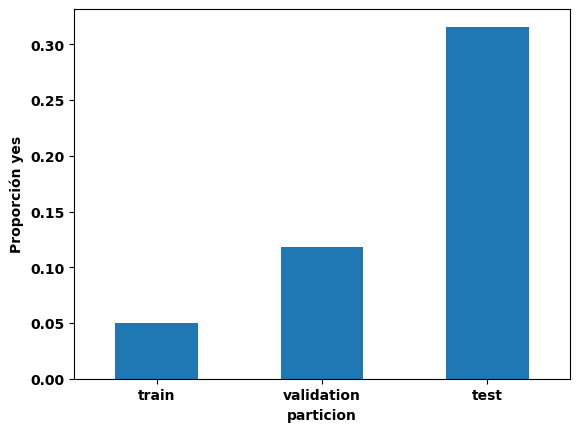

In [4]:
display(data.groupby("y").duration.agg(["count","mean","median"]))
import matplotlib.pyplot as plt
summary.plot.bar(x="particion",y="prevalencia",rot=0,legend=False)
plt.ylabel("Proporción yes");plt.show()

## Reflexión
¿Qué cambia entre particiones? ¿Qué incertidumbre introduce no tener identificador de persona? Evite afirmar causalidad sin evidencia.